In [1]:
# mount google drive and set up paths
from rich.traceback import install
install()

from google.colab import drive
drive.mount('/content/drive')

import os
from pathlib import Path
import numpy as np
import torch
import torchvision
import matplotlib.pyplot as plt
import cv2
import sys

# persistent paths on drive
DRIVE_BASE = Path('/content/drive/MyDrive/sam_setup')
SAM_REPO_PATH = DRIVE_BASE / 'segment_anything'
CHECKPOINT_PATH = DRIVE_BASE / 'sam_vit_h_4b8939.pt'
LIGHTGLUE_PATH = DRIVE_BASE / 'LightGlue'

# has 3 images flm_refl.png, flm_rgb.png(reflection, green, blue channel image), tem.png
INPUT_DIR = Path('/content/drive/MyDrive/flm_tem_correlation')

DRIVE_BASE.mkdir(exist_ok=True, parents=True)

Mounted at /content/drive


In [2]:
import sys

if not os.path.exists(SAM_REPO_PATH):
    print("Cloning SAM repo to Drive (one-time setup)...")
    !git clone https://github.com/facebookresearch/segment-anything.git {SAM_REPO_PATH}
else:
    print("SAM repo found on Drive, skipping clone.")

sys.path.append(str(SAM_REPO_PATH)) # sys.path needs a string dummy
!pip install -e {str(SAM_REPO_PATH)} -q # here as well

SAM repo found on Drive, skipping clone.
  Preparing metadata (setup.py) ... done


In [3]:
if not os.path.exists(CHECKPOINT_PATH):
    print("Downloading SAM checkpoint to Drive (one-time setup)...")
    !wget -q https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth -O {CHECKPOINT_PATH}
else:
    print("Checkpoint found on Drive, skipping download.")

Checkpoint found on Drive, skipping download.


In [4]:
if not LIGHTGLUE_PATH.exists():
    print("Cloning LightGlue to Drive (one-time setup)...")
    !git clone --quiet https://github.com/cvg/LightGlue/ {LIGHTGLUE_PATH}
else:
    print("LightGlue found on Drive, skipping clone.")

sys.path.append(str(LIGHTGLUE_PATH))
!pip install --progress-bar off --quiet -e {LIGHTGLUE_PATH}

LightGlue found on Drive, skipping clone.
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for lightglue (pyproject.toml) ... done


In [5]:
from lightglue import LightGlue, SuperPoint, DISK
from lightglue.utils import load_image, rbd
from lightglue import viz2d

torch.set_grad_enabled(False)

torch.autograd.grad_mode.set_grad_enabled(mode=False)

In [6]:
from segment_anything import sam_model_registry, SamPredictor, SamAutomaticMaskGenerator

device = 'cuda' if torch.cuda.is_available() else 'cpu'
sam = sam_model_registry["vit_h"](checkpoint=CHECKPOINT_PATH)
_ = sam.to(device=device)

In [8]:
mask_generator = SamAutomaticMaskGenerator(
    model=sam,
    points_per_side=32,
    pred_iou_thresh=0.86,
    stability_score_thresh=0.92,
    # crop_n_layers=1,
    # crop_n_points_downscale_factor=2,
    # min_mask_region_area=100
)

In [ ]:
def show_anns(anns):
    if len(anns) == 0:
        return
    sorted_anns = sorted(anns, key=(lambda x: x['area']), reverse=True)
    ax = plt.gca()
    ax.set_autoscale_on(False)

    img = np.ones((sorted_anns[0]['segmentation'].shape[0], sorted_anns[0]['segmentation'].shape[1], 4))
    img[:,:,3] = 0
    for ann in sorted_anns:
        m = ann['segmentation']
        color_mask = np.concatenate([np.random.random(3), [0.35]])
        img[m] = color_mask
    ax.imshow(img)

def show_image(path, figsize=(5, 5)) -> None:
    """shows image and returns back the array"""
    image = cv2.imread(path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=figsize)
    plt.imshow(image)
    plt.axis('off')
    plt.show()
    return image

def show_mask_over_image(masks, image, figsize=(5, 5)):
    plt.figure(figsize=figsize)
    plt.imshow(image)
    show_anns(masks)
    plt.axis('off')
    plt.show()

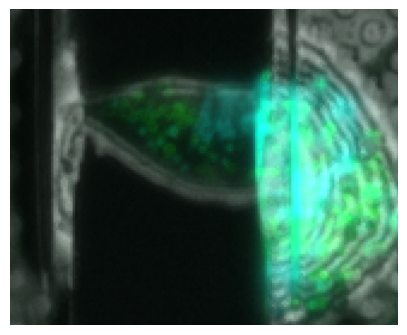

In [ ]:
img_flm = show_image(INPUT_DIR / 'flm_rgb.png')

In [ ]:
mask_flm = mask_generator.generate(img_flm)

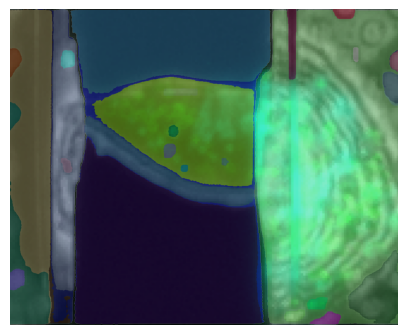

In [ ]:
show_mask_over_image(mask_flm, img_flm)

In [ ]:
# arrange the masks by the decreasing area
mask_flm = sorted(mask_flm, key=lambda x: -x['area'])

In [ ]:
len(mask_flm)

32

╭─────────────────────────────── Traceback (most recent call last) ────────────────────────────────╮
│ in <cell line: 0>:7                                                                              │
│                                                                                                  │
│   4 │   row = i // 4                                                                             │
│   5 │   col = i % 4                                                                              │
│   6 │                                                                                            │
│ ❱ 7 │   ax[row, col].imshow(mask_flm[i]['segmentation'], cmap='gray')                            │
│   8                                                                                              │
╰──────────────────────────────────────────────────────────────────────────────────────────────────╯
IndexError: index 4 is out of bounds for axis 0 with size 4

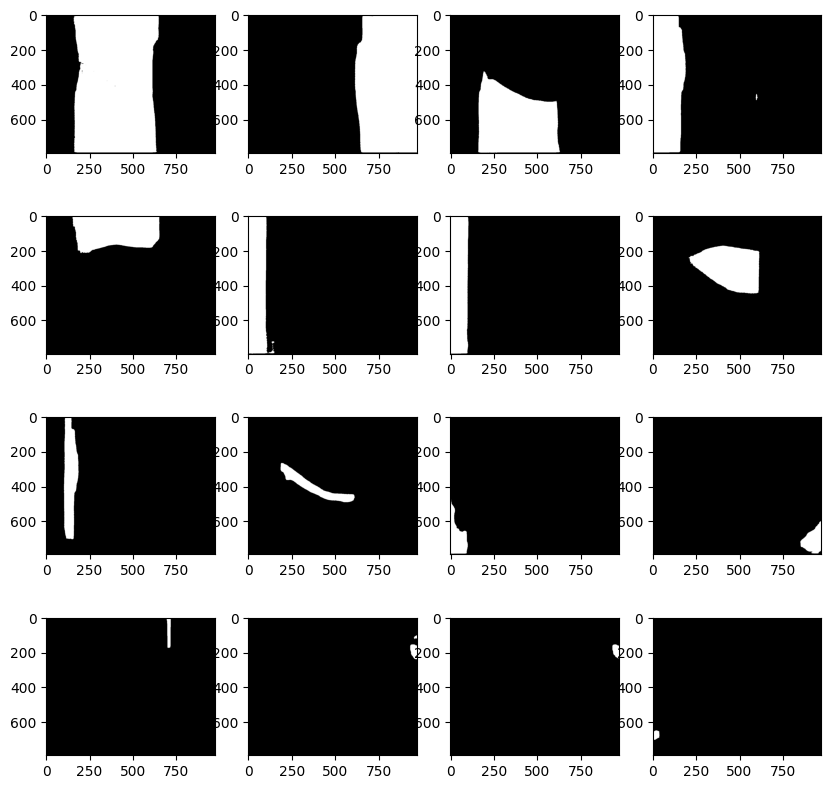

In [ ]:
# total 13 masks 4 x 3 grid
fig, ax = plt.subplots(4, 4, figsize=(10, 10))
for i in range(len(mask_flm)):
    row = i // 4
    col = i % 4

    ax[row, col].imshow(mask_flm[i]['segmentation'], cmap='gray')

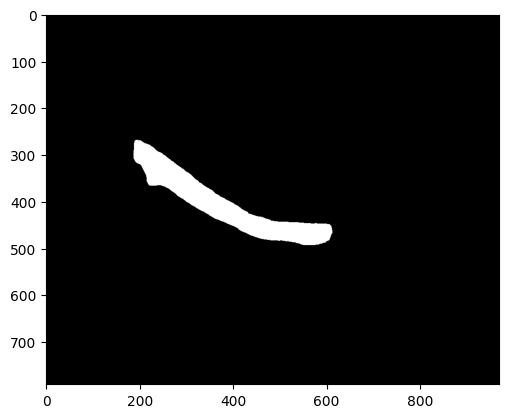

In [ ]:
plt.imshow(mask_flm[9]['segmentation'], cmap='gray')

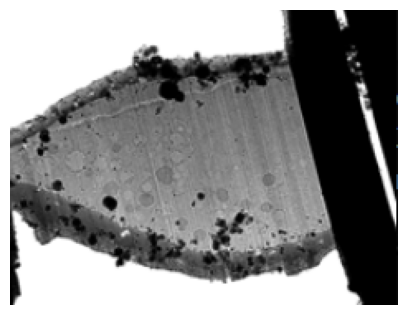

In [ ]:
img_tem = show_image(INPUT_DIR / 'tem.png')

In [ ]:
mask_tem = mask_generator.generate(img_tem)

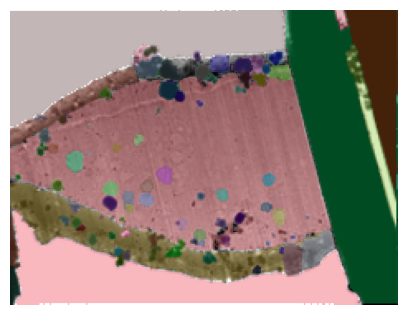

In [ ]:
show_mask_over_image(mask_tem, img_tem)

In [ ]:
# arrange the masks by the decreasing area
mask_tem = sorted(mask_tem, key=lambda x: -x['area'])

In [ ]:
len(mask_tem)

103

╭─────────────────────────────── Traceback (most recent call last) ────────────────────────────────╮
│ in <cell line: 0>:6                                                                              │
│                                                                                                  │
│   3 for i in range(len(mask_tem)):                                                               │
│   4 │   row = i // 4                                                                             │
│   5 │   col = i % 4                                                                              │
│ ❱ 6 │   ax[row, col].imshow(mask_tem[i]['segmentation'], cmap='gray')                            │
│   7                                                                                              │
╰──────────────────────────────────────────────────────────────────────────────────────────────────╯
IndexError: index 4 is out of bounds for axis 0 with size 4

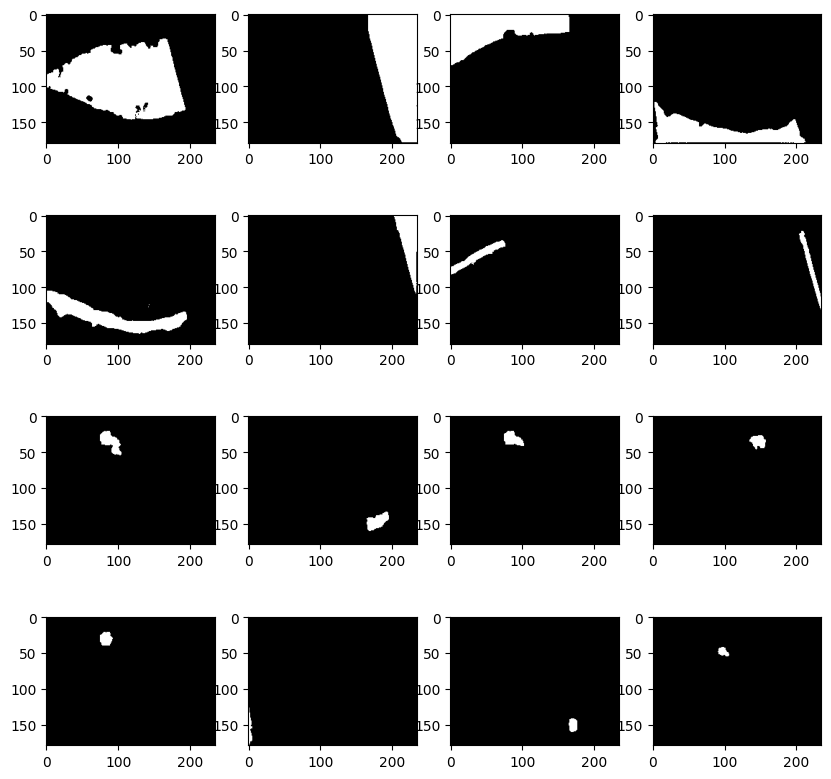

In [ ]:
# total 13 masks 4 x 3 grid
fig, ax = plt.subplots(4, 4, figsize=(10, 10))
for i in range(len(mask_tem)):
    row = i // 4
    col = i % 4
    ax[row, col].imshow(mask_tem[i]['segmentation'], cmap='gray')

In [ ]:
extractor = SuperPoint(max_num_keypoints=2048).eval().to(device)  # load the extractor
matcher = LightGlue(features="superpoint").eval().to(device)
# matcher = LightGlue(
#     features="superpoint",
#     depth_confidence=-1,   # disable early stopping
#     width_confidence=-1,    # disable pruning
#     filter_threshold=0.1,
# ).eval().to(device)

In [ ]:
def create_tensor_from_mask(mask):
    image = np.stack((mask,) * 3, axis=0)
    return torch.from_numpy(image).to(dtype=torch.float32)

def get_keypoint_matches(image0, image1):
    feats0 = extractor.extract(image0.to(device))
    feats1 = extractor.extract(image1.to(device))
    matches01 = matcher({"image0": feats0, "image1": feats1})
    feats0, feats1, matches01 = [
        rbd(x) for x in [feats0, feats1, matches01]
    ]  # remove batch dimension

    kpts0, kpts1, matches = feats0["keypoints"], feats1["keypoints"], matches01["matches"]
    m_kpts0, m_kpts1 = kpts0[matches[..., 0]], kpts1[matches[..., 1]]
    return kpts0, kpts1, m_kpts0, m_kpts1, matches01

In [ ]:
image0 = create_tensor_from_mask(mask_flm[7]['segmentation'])
image1 = create_tensor_from_mask(mask_tem[0]['segmentation'])

In [ ]:
image0.shape, image1.shape

(torch.Size([3, 791, 970]), torch.Size([3, 179, 235]))

In [ ]:
kpts0, kpts1, m_kpts0, m_kpts1, matches01 = get_keypoint_matches(image0, image1)

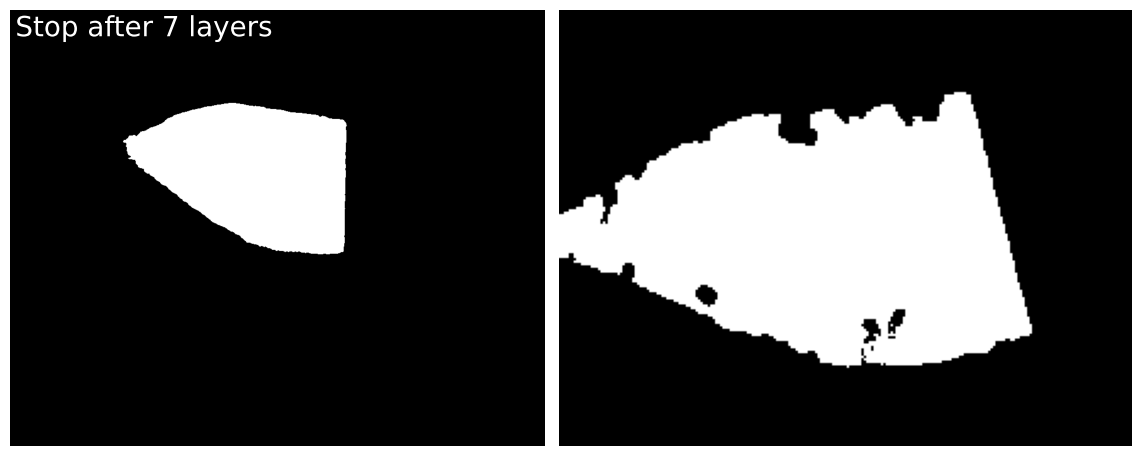

In [ ]:
axes = viz2d.plot_images([image0, image1])
viz2d.plot_matches(m_kpts0, m_kpts1, color="lime", lw=0.3)
viz2d.add_text(0, f'Stop after {matches01["stop"]} layers', fs=20)

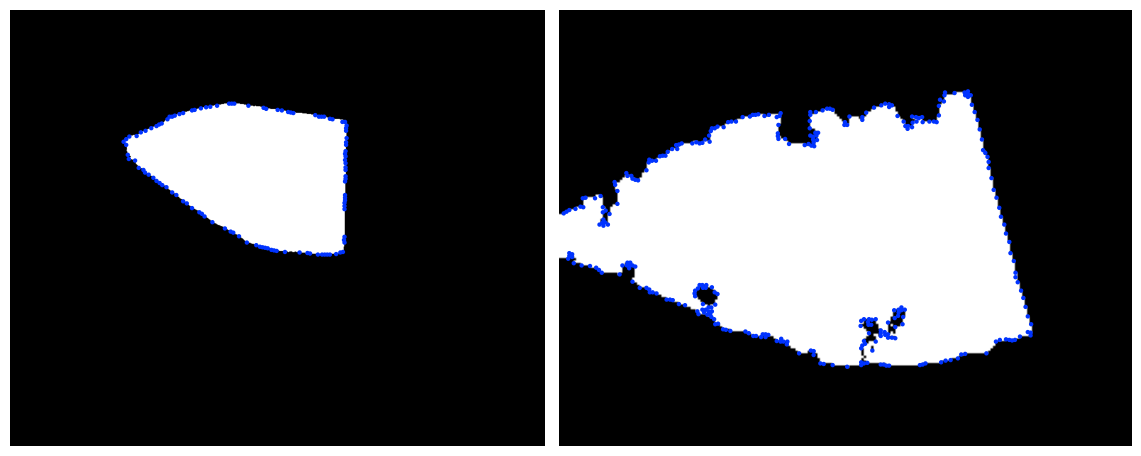

In [ ]:
kpc0, kpc1 = viz2d.cm_prune(matches01["prune0"]), viz2d.cm_prune(matches01["prune1"])
viz2d.plot_images([image0, image1])
viz2d.plot_keypoints([kpts0, kpts1], colors=[kpc0, kpc1], ps=10)

In [ ]:
# run for 10 x 10 pairs and find the pair that has maximum number of keypoint matches
max_points = 0
f, t = None, None
for i in range(10):
    for j in range(10):
        image0 = create_tensor_from_mask(mask_flm[i]['segmentation'])
        image1 = create_tensor_from_mask(mask_tem[j]['segmentation'])
        m_kpts0, m_kpts1, matches01 = get_keypoint_matches(image0, image1)
        if len(m_kpts0) > max_points:
            max_points = len(m_kpts0)
            f = i
            t = j
